1. Load libraries and settings
2. Analyze the sensor reading and dataset
3. Summary

In [43]:
#Loading Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [44]:
#Settings
sns.set(style='whitegrid', palette='Set2', font_scale=1.2)
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

#Upload the dataset
data_path = Path("C:\\Users\\hp\\OneDrive\\Documents\\Inuka Tech\\Data Analytics\\Week 2\\week2_sensor_readings.csv")

In [45]:
#Creating our own path
DATA_DIR = Path("C:\\Users\\hp\\OneDrive\\Documents\\Inuka Tech\\Data Analytics\\Week 2")
SENSOR_FILE = DATA_DIR / "week2_sensor_readings.csv"

Loading the data - Look at the data

In [46]:
#Load the dataset
sensor_df = pd.read_csv(DATA_DIR / "week2_sensor_readings.csv")
sensor_df.head(15)

,timestamp,sensor_id,reading,location,shift
0,01/06/2026 00:00,Pressure_01,54.97,mombasa,Afternoon
1,01/06/2026 00:05,Pressure_01,48.62,NRB,Morning
2,01/06/2026 00:10,temp_sensor,56.48,Nairobi,Morning
3,01/06/2026 00:15,P1,65.23,mombasa,Morning
4,01/06/2026 00:20,P1,47.66,mombasa,Night
5,01/06/2026 00:25,P1,47.66,MBA,Morning
6,01/06/2026 00:30,Pressure_01,65.79,Kisumu,Morning
7,01/06/2026 00:35,Pressure_01,57.67,mombasa,Night
8,01/06/2026 00:40,TEMP_SENS,45.31,Nairobi,Morning
9,01/06/2026 00:45,Pressure_01,55.43,Mombasa,Night


In [47]:
#structure of the dataset
sensor_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  2000 non-null   str    
 1   sensor_id  2000 non-null   str    
 2   reading    2000 non-null   float64
 3   location   2000 non-null   str    
 4   shift      2000 non-null   str    
dtypes: float64(1), str(4)
memory usage: 78.3 KB


Set the timestamp into date

In [48]:
#Data profile
sensor_profile = pd.DataFrame(
    {
        "metric": [
            "rows",
            "columns",
            "start timestamp",
            "end timestamp",
            "duplicate rows",
            "missing values",
            "missing values (%)",
            "unique values",
            "unique values (%)",
            "reading mean",
            "reading median",
            "reading mode",
            "reading min",
            "reading max",
            "reading std",
            "reading variance",
        ],
        "value": [
            sensor_df.shape[0],
            sensor_df.shape[1],
            sensor_df["timestamp"].min(),
            sensor_df["timestamp"].max(),
            sensor_df.duplicated().sum(),
            sensor_df.isna().sum().sum(),
            sensor_df.isna().mean().mean() * 100,
            sensor_df.nunique().sum(),
            sensor_df.nunique().sum() / sensor_df.size * 100,
            sensor_df["reading"].mean(),
            sensor_df["reading"].median(),
            sensor_df["reading"].mode().iloc[0] if not sensor_df["reading"].mode().empty else None,
            sensor_df["reading"].min(),
            sensor_df["reading"].max(),
            sensor_df["reading"].std(),
            sensor_df["reading"].var(),
        ],
    }
)

sensor_profile

,metric,value
0,rows,2000
1,columns,5
2,start timestamp,01/06/2026 00:00
3,end timestamp,07/06/2026 22:35
4,duplicate rows,0
5,missing values,0
6,missing values (%),0.00
7,unique values,4013
8,unique values (%),40.13
9,reading mean,50.45


Check for missing values

In [49]:
sensor_df.isna().sum().to_frame(name='missing_values')

,missing_values
timestamp,0
sensor_id,0
reading,0
location,0
shift,0


Standardize Data

In [55]:
# See all column names
print(sensor_df.columns.tolist())

# Or with display
display(sensor_df.head())

['timestamp', 'sensor_id', 'reading', 'location', 'shift', 'location_clean']


,timestamp,sensor_id,reading,location,shift,location_clean
0,01/06/2026 00:00,Pressure_01,54.97,mombasa,Afternoon,mombasa
1,01/06/2026 00:05,Pressure_01,48.62,NRB,Morning,Nairobi
2,01/06/2026 00:10,temp_sensor,56.48,Nairobi,Morning,Nairobi
3,01/06/2026 00:15,P1,65.23,mombasa,Morning,mombasa
4,01/06/2026 00:20,P1,47.66,mombasa,Night,mombasa


In [61]:
sensor_df['location_clean'] = sensor_df['location'].replace({
    'MBA': 'Mombasa', 
    'mombasa': 'Mombasa',
    'NRB': 'Nairobi', 
    'KSM': 'Kisumu'
})

sensor_df['sensor_clean'] = sensor_df['sensor_id'].replace({
    'temp_1': 'Temp_sensor', 
    'P1': 'Pressure_01', 
    'TEMP_SENS': 'Temp_sensor',
    'Temperature_Sensor': 'Temp_sensor',
    'temp_sensor': 'Temp_sensor',
})
sensor_df['sensor_name'] = sensor_df['sensor_clean'] 

display(sensor_df['location_clean'].value_counts())
display(sensor_df['sensor_clean'].value_counts())

location_clean
Mombasa    1005
Nairobi     654
Kisumu      341
Name: count, dtype: int64

sensor_clean
Temp_sensor    1033
Pressure_01     967
Name: count, dtype: int64

#Reading Pattern by shift

In [62]:
sensor_shift_summary = (
    sensor_df.groupby("shift")["reading"]
    .agg(["count", "mean", "median", "std",])
    .round(2)
)
sensor_shift_summary

,count,mean,median,std
shift,,,,
Afternoon,632,49.90,49.84,9.73
Morning,639,51.03,51.15,10.38
Night,729,50.42,50.13,9.55


#Reading patterns by Cleaned location and Sensor

In [64]:
sensor_location_summary = (
    sensor_df.groupby("location_clean")["reading"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)
sensor_location_summary

,count,mean,median,std
location_clean,,,,
Kisumu,341,50.75,50.70,9.72
Mombasa,1005,50.46,50.64,9.54
Nairobi,654,50.28,49.92,10.49


#Oulier Check

In [65]:
q1 = sensor_df['reading'].quantile(0.25)
q3 = sensor_df['reading'].quantile(0.75)
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr 
upper_fence = q3 + 1.5 * iqr #set the upper fence for outliers

sensor_outliers = sensor_df[
    (sensor_df['reading'] < lower_fence) | (sensor_df['reading'] > upper_fence)
]
print(f"Lower fence: {lower_fence: .2f}"), 
print(f"Upper fence: {upper_fence: .2f}")
sensor_outliers

Lower fence:  24.19
Upper fence:  76.41


,timestamp,sensor_id,reading,location,shift,location_clean,sensor_clean,sensor_name
74,01/06/2026 06:10,Pressure_01,23.80,Nairobi,Night,Nairobi,Pressure_01,Pressure_01
179,01/06/2026 14:55,TEMP_SENS,77.20,MBA,Morning,Mombasa,Temp_sensor,Temp_sensor
209,01/06/2026 17:25,TEMP_SENS,88.53,Nairobi,Morning,Nairobi,Temp_sensor,Temp_sensor
262,01/06/2026 21:50,temp_sensor,17.59,Mombasa,Afternoon,Mombasa,Temp_sensor,Temp_sensor
478,02/06/2026 15:50,TEMP_SENS,80.79,NRB,Morning,Nairobi,Temp_sensor,Temp_sensor
646,03/06/2026 05:50,TEMP_SENS,23.03,NRB,Afternoon,Nairobi,Temp_sensor,Temp_sensor
668,03/06/2026 07:40,TEMP_SENS,23.49,NRB,Morning,Nairobi,Temp_sensor,Temp_sensor
1061,04/06/2026 16:25,temp_sensor,21.51,Nairobi,Afternoon,Nairobi,Temp_sensor,Temp_sensor
1101,04/06/2026 19:45,Pressure_01,21.04,Nairobi,Afternoon,Nairobi,Pressure_01,Pressure_01
1355,05/06/2026 16:55,P1,24.09,Mombasa,Night,Mombasa,Pressure_01,Pressure_01


#Data Visualization

ValueError: Invalid frequency: H. Failed to parse with error message: ValueError("Invalid frequency: H. Failed to parse with error message: KeyError('H'). Did you mean h?") Did you mean h?

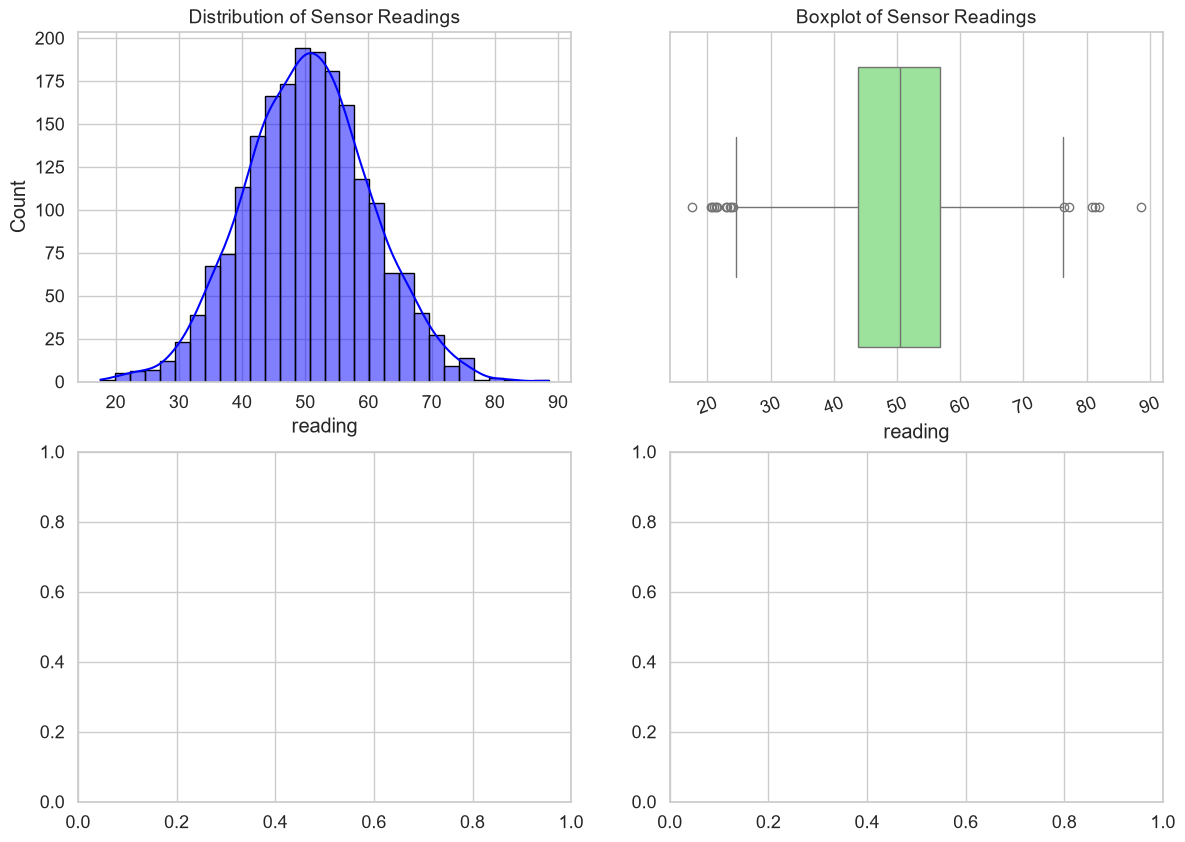

In [68]:
#Histogram of the sensor readings distribution
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(sensor_df['reading'], bins=30, kde=True, ax=ax[0, 0], color='blue', edgecolor='black')
ax[0, 0].set_title('Distribution of Sensor Readings', fontsize=14)

#Boxplot of the cleaned sensor readings
sns.boxplot(x='reading', data=sensor_df, ax=ax[0, 1], color='lightgreen')
ax[0, 1].set_title('Boxplot of Sensor Readings', fontsize=14)    
ax[0, 1].tick_params(axis='x', rotation=20)

#Sensor hourly reading
sensor_df['timestamp_dt'] = pd.to_datetime(sensor_df['timestamp'], format='%d/%m/%Y %H:%M')
sensor_hourly = sensor_df.groupby(sensor_df['timestamp_dt'].dt.floor('H'))['reading'].mean().reset_index()
sensor_hourly.columns = ['timestamp', 'reading']
sensor_hourly.plot(x='timestamp', y='reading', kind='line', ax=ax[1, 0], color='orange')
ax[1, 0].set_title('Average Sensor Reading by Hour', fontsize=14)
ax[1, 0].set_xlabel('Timestamp (Hour)', fontsize=12)
ax[1, 0].set_ylabel('Average Reading', fontsize=12)

plt.tight_layout()
plt.show()